<a href="https://colab.research.google.com/github/federico2018lc/Proyecto-Integrador---2026-/blob/main/ProyectoIntegrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Proyecto Integrador**

## Extraction (ETL)


In [ ]:
# Importación de Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno    #para que es??

In [ ]:
### Importar un dataset csv desde GitHub
url='https://raw.githubusercontent.com/matirova/gitispc/refs/heads/main/datos/Contracargos2025-26.csv.xls'
df= pd.read_csv(url,sep=',')
df.head()

,ID_OP,Clase,Fecha del pago,Condicion,Monto pagado,conciliacion,Motivo,Medio de pago,Numero de tarjeta,Fecha de vencimiento,Tipo de tarjeta,Recurrencia,Nombre Comprador,Mail Comprador,Direccion comprador,Complemento de direccion del comprador,Pais del comprador,Adquiriente,Opciones de Pago,Comercio
0,9yltsm,Cargo,2025-11-09 14:07:41,Capturado,20000,contracargo,NaN,VISA_DEBIT,4040XXXXXXXX1463,2027-01-01,Tarjeta prepago /,NaN,herxxGer,herxxGer@gmail.com,NaN,NaN,AR,Adquiriente2,"1 cuota de $20.000,00 ($20.000,00)",Comercio11
1,9orzst,Cargo,2025-11-09 14:09:13,Capturado,25000,contracargo,NaN,VISA_DEBIT,4040XXXXXXXX1463,2027-01-01,Tarjeta prepago /,NaN,herxxGer,herxxGer@gmail.com,NaN,NaN,AR,Adquiriente2,"1 cuota de $25.000,00 ($25.000,00)",Comercio11
2,919517,Cargo,2025-10-15 06:44:03,Capturado,1000,contracargo,NaN,MASTERCARD_DEBIT,5149XXXXXXXX0208,2026-10-01,Tarjeta de débito / Particular,NaN,losxxAle,losxxAle@gmail.com,NaN,NaN,AR,Adquiriente1,"1 cuota de $1.000,00 ($1.000,00)",Comercio5
3,900479,Cargo,2025-10-15 07:11:11,Capturado,1000,contracargo,NaN,MASTERCARD_DEBIT,5149XXXXXXXX0208,2026-10-01,Tarjeta de débito / Particular,NaN,losxxAle,losxxAle@gmail.com,NaN,NaN,AR,Adquiriente1,"1 cuota de $1.000,00 ($1.000,00)",Comercio5
4,938265,Cargo,2025-10-15 07:11:54,Capturado,2000,contracargo,NaN,MASTERCARD_DEBIT,5149XXXXXXXX0208,2026-10-01,Tarjeta de débito / Particular,NaN,losxxAle,losxxAle@gmail.com,NaN,NaN,AR,Adquiriente1,"1 cuota de $2.000,00 ($2.000,00)",Comercio5


In [ ]:
df.columns

Index(['ID_OP', 'Clase', 'Fecha del pago', 'Condicion', 'Monto pagado',
       'conciliacion', 'Motivo', 'Medio de pago', 'Numero de tarjeta',
       'Fecha de vencimiento', 'Tipo de tarjeta', 'Recurrencia',
       'Nombre Comprador', 'Mail Comprador', 'Direccion comprador',
       'Complemento de direccion del comprador', 'Pais del comprador',
       'Adquiriente', 'Opciones de Pago', 'Comercio'],
      dtype='object')

##Transformation


- Busqueda de datos faltantes, duplicados y erroneos.
- Selección de Columnas de interes.
- Establecer formato para fechas.
- Renombrar las columnas. (hay una columna que termina con un espacio de más)
- etc

###1. Visualización de Datos Faltantes

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3698 entries, 0 to 3697
Data columns (total 20 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ID_OP                                   3698 non-null   object 
 1   Clase                                   314 non-null    object 
 2   Fecha del pago                          3698 non-null   object 
 3   Condicion                               3698 non-null   object 
 4   Monto pagado                            3698 non-null   int64  
 5   conciliacion                            3698 non-null   object 
 6   Motivo                                  0 non-null      float64
 7   Medio de pago                           3698 non-null   object 
 8   Numero de tarjeta                       3698 non-null   object 
 9   Fecha de vencimiento                    314 non-null    object 
 10  Tipo de tarjeta                         314 non-null    obje

<Axes: >

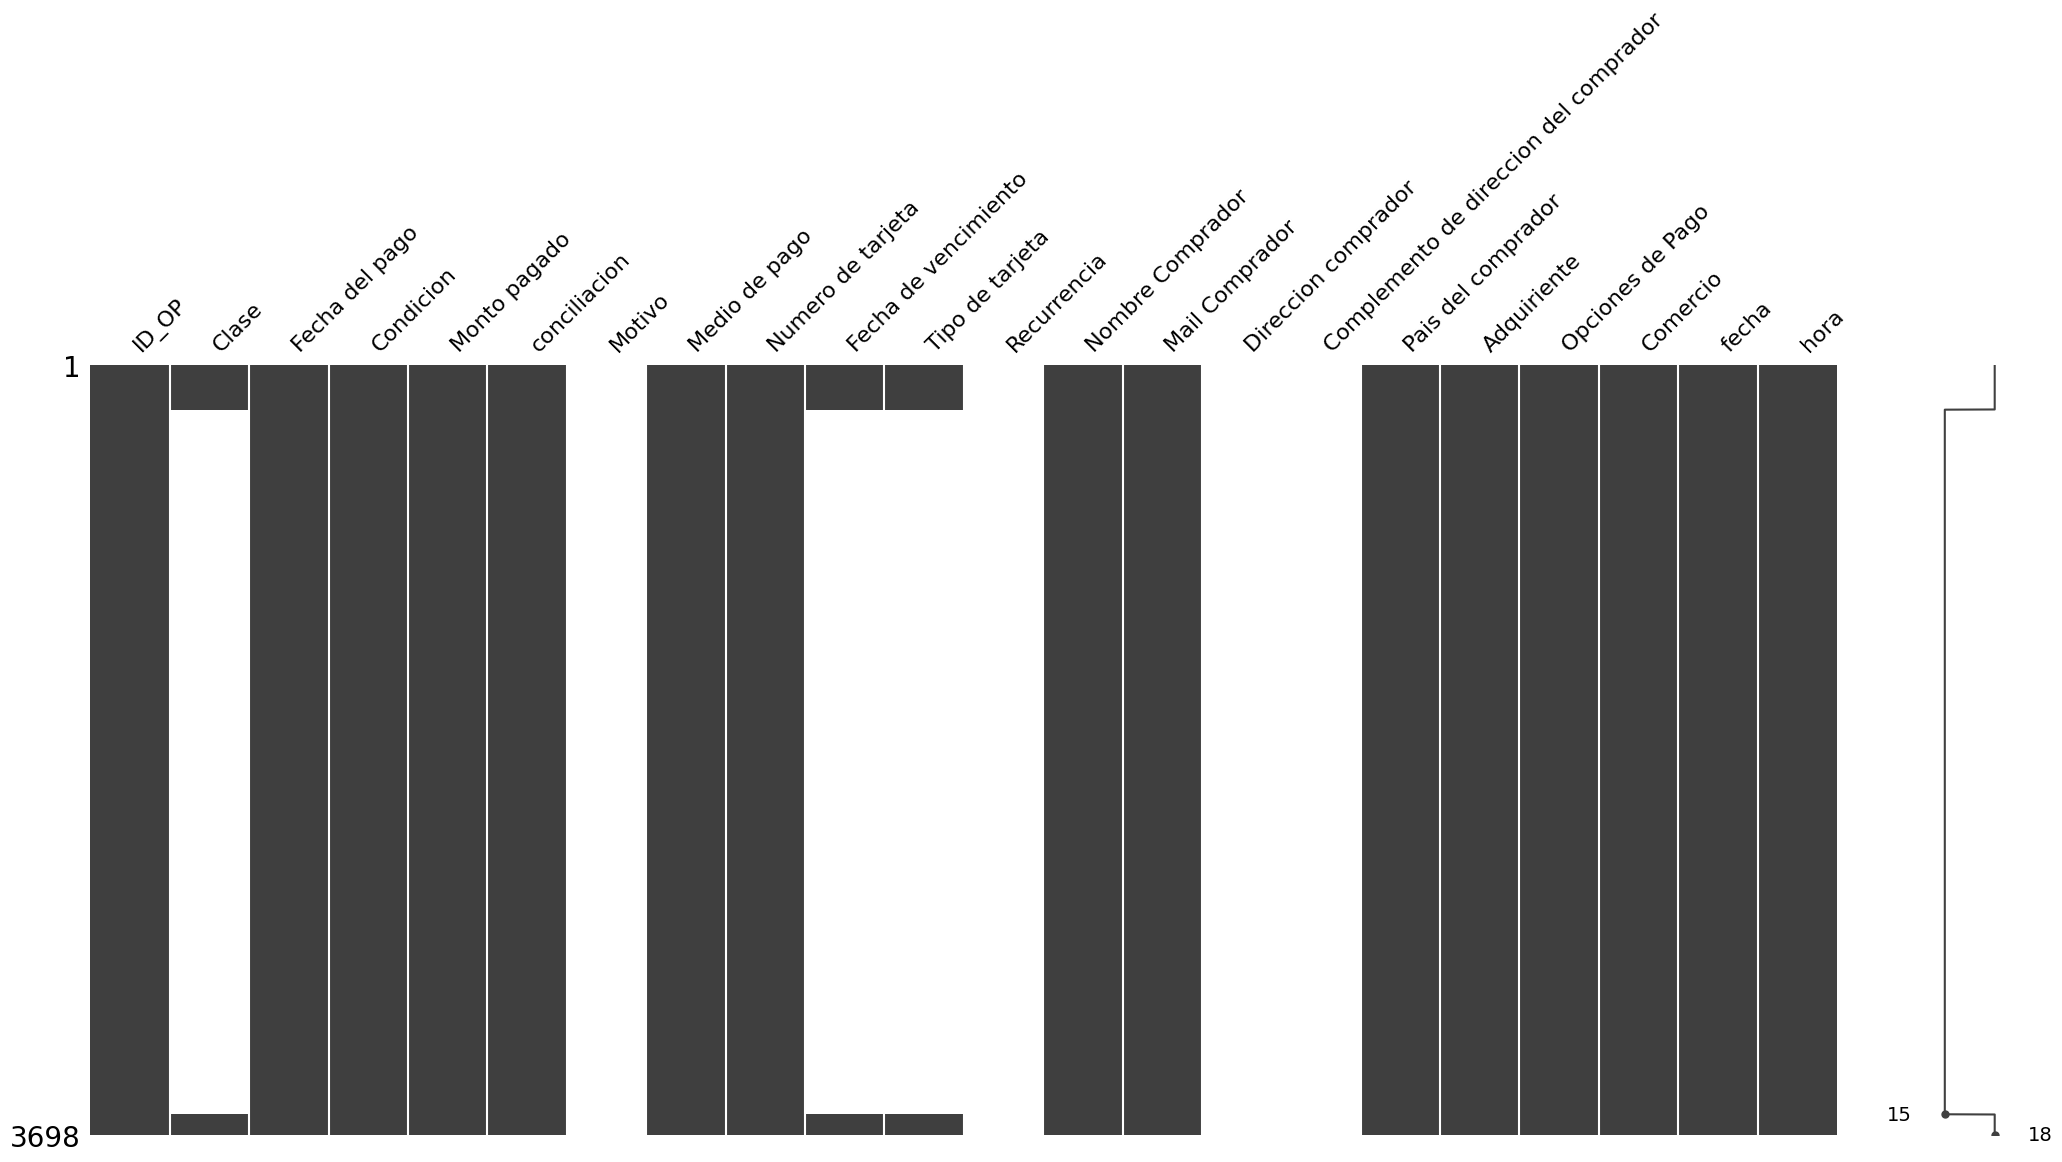

In [ ]:
msno.matrix(df)

<Axes: >

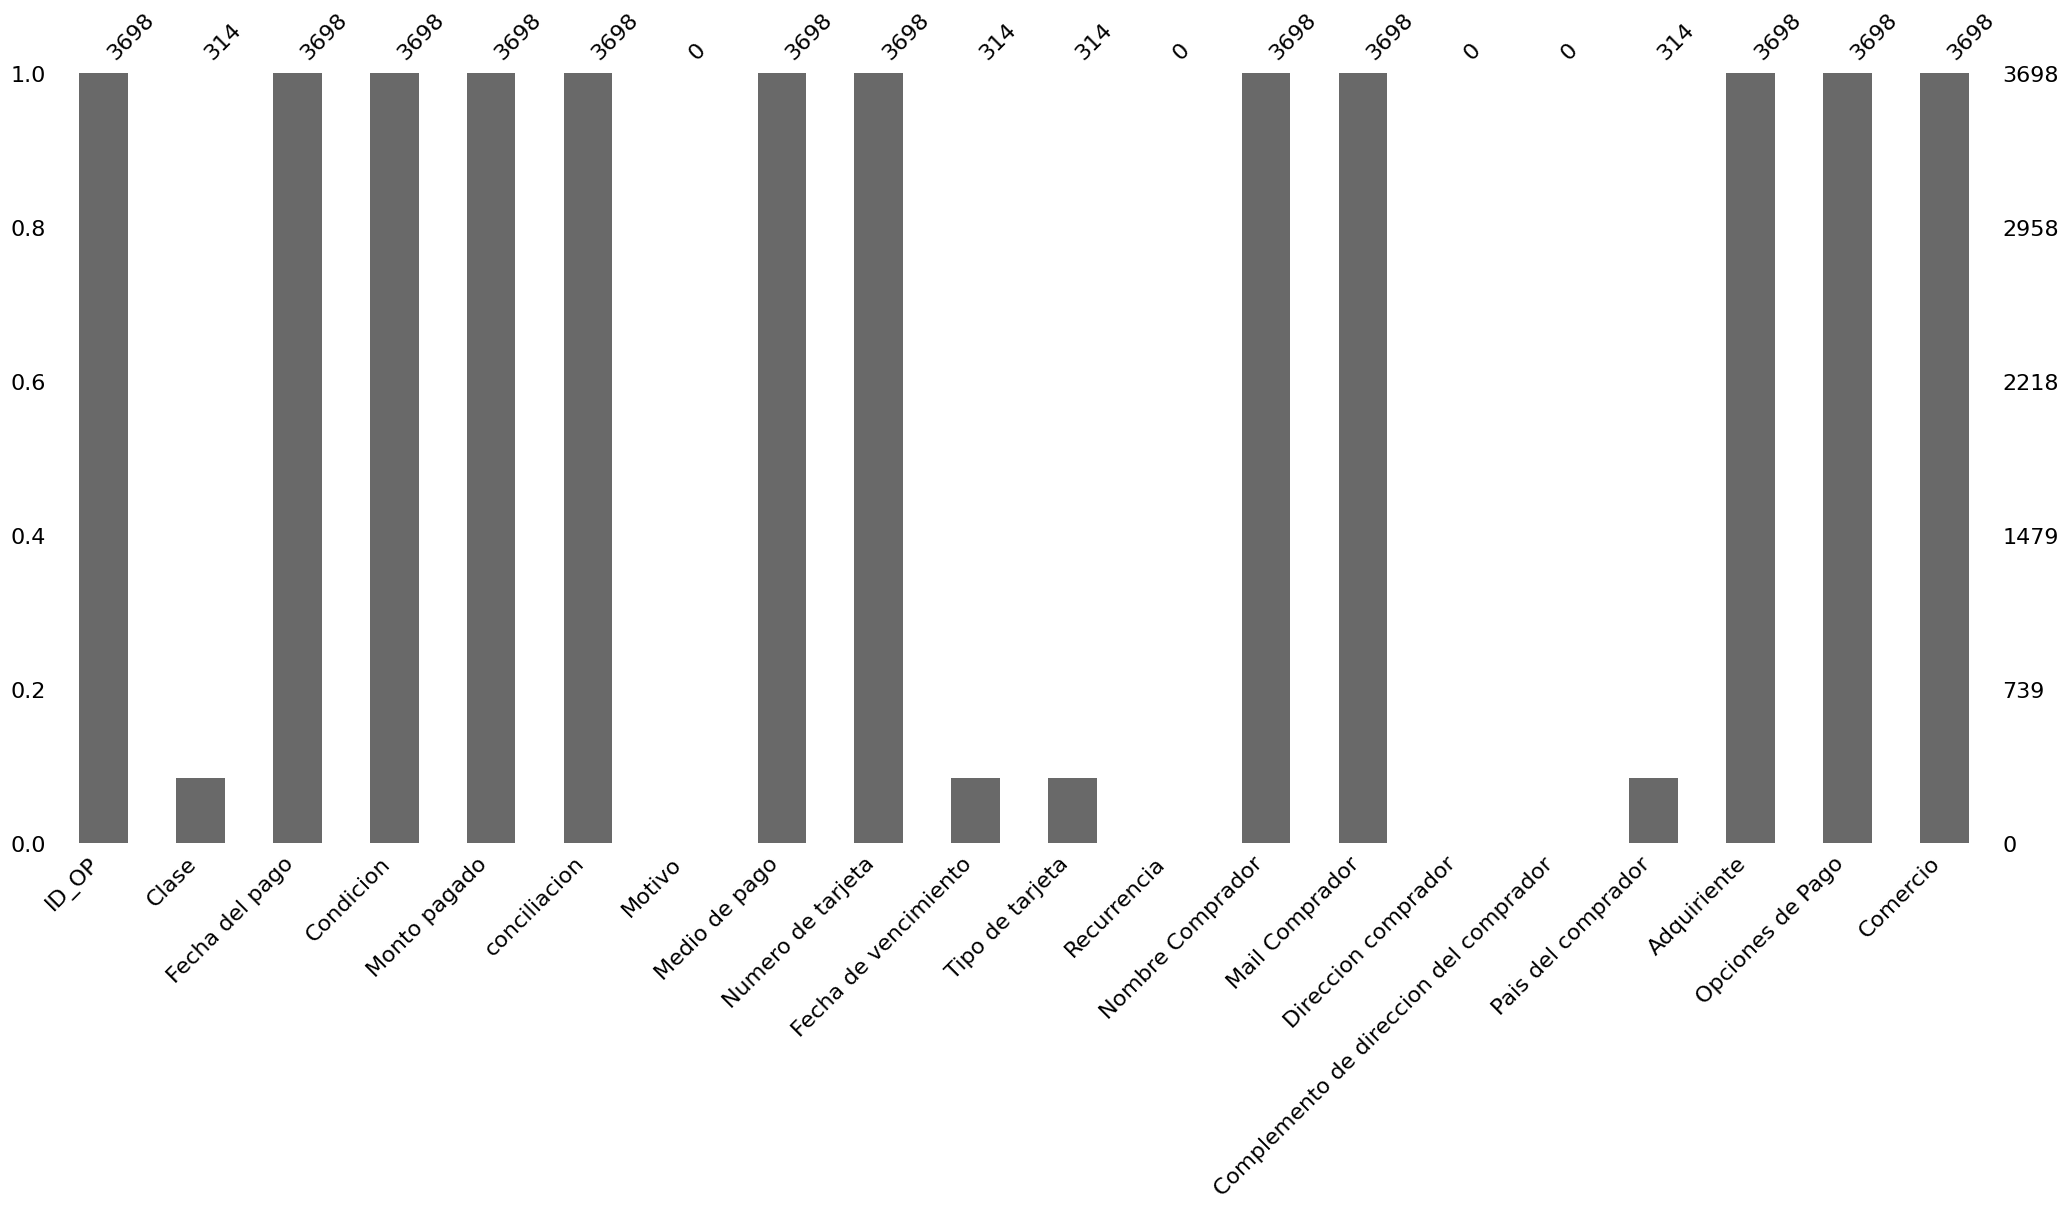

In [ ]:
msno.bar(df)

###2. Completando datos faltantes de *País*

In [ ]:
df['Pais del comprador'].value_counts()

,count
Pais del comprador,
AR,314


In [ ]:
df['Pais del comprador'] = df['Pais del comprador'].fillna('AR')
df['Pais del comprador'].value_counts()

,count
Pais del comprador,
AR,3698


###3. Estandarización de Condición

In [ ]:
df['Condicion'].value_counts()

,count
Condicion,
CAPTURED,3384
Capturado,314


In [ ]:
df.loc[df['Condicion'] == 'Capturado', 'Condicion'] = 'CAPTURED'
df['Condicion'].value_counts()

,count
Condicion,
CAPTURED,3698


### 4. Eliminación de duplicados - ¿Tiene sentido que en este dataset haya datos duplicados?
No tiene sentido en este dataset haya datos duplicados ya que cada registro fila representa una transacción con un único numero de ID_OP. Por lo tanto filas duplicados significaria transacciones repetidas.


In [ ]:
cantidad_duplicados = df.duplicated().sum()

print(f"Cantidad de registros fila duplicados: {cantidad_duplicados}")

Cantidad de registros fila duplicados: 117


In [ ]:
df = df.drop_duplicates()
cantidad_duplicados = df.duplicated().sum()

print(f"Cantidad de registros fila duplicados: {cantidad_duplicados}")

Cantidad de registros fila duplicados: 0


###5. Separar Fecha Hora y cambiar type a datetime

In [ ]:
print(df['Fecha del pago'].dtype)

datetime64[ns]


In [ ]:
df['Fecha del pago'] = pd.to_datetime(df['Fecha del pago'])
df['fecha'] = df['Fecha del pago'].dt.date
df['hora'] = df['Fecha del pago'].dt.time
print(df['fecha'].dtype)
print(df['hora'].dtype)

object
object


In [ ]:
df['fecha'] = pd.to_datetime(df['fecha'])
df['hora'] = pd.to_datetime(df['hora'], format='%H:%M:%S')
print(df['fecha'].dtype)
print(df['hora'].dtype)

datetime64[ns]
datetime64[ns]


#### Validación

In [ ]:
# validar errores
print('Hay',df['fecha'].isna().sum(),'fechas nulas o erroneas')

# validar operaciones datetime
print('Para ver que el type sea correcto tiene que poder reconocer el año de cada fecha.')
print(df['fecha'].dt.year.head(3))

Hay 0 fechas nulas o erroneas
Para ver que el type sea correcto tiene que poder reconocer el año de cada fecha.
0    2025
1    2025
2    2025
Name: fecha, dtype: int32


### 6. Eliminación de columnas (Mariela)


###7. Renombrar columnas - EMA

Recordatorio: "Este paso puede tener que volver a repetirse en otros momentos por errores de espacios no visibles"

###8. Estandarización - Busqueda de datos anomalos. ¿Tienen sentido los datos?

Mati

### 9. Arreglos sobre datos faltantes


## Load


Se subira el df en formato csv a github para que todos tengan acceso.


 # **Análisis del primer Excel - no usar este para las evidencias!
 **


In [ ]:
import pandas as pd
# Ruta del archivo en Colab (ajusta el nombre)
ruta = '/content/Contracargos26.xlsx'
# Leer la primera hoja
df = pd.read_excel(ruta, engine='openpyxl')  # openpyxl recomendado para .xlsx
df.shape

FileNotFoundError: [Errno 2] No such file or directory: '/content/Contracargos26.xlsx'

In [ ]:
df.to_csv("Contracargos2026.csv", index=False)

In [ ]:
df = pd.read_csv('/content/Contracargos2025-2026.csv')  # openpyxl recomendado para .xlsx
df.shape

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df = pd.concat([df, df.iloc[:100]])

In [ ]:
df.info()

In [ ]:
df.to_csv("Contracargos2025-2026.csv", index=False)

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Contracargos2025-2026.csv')
df.shape

In [ ]:
df = pd.read_csv('/content/Contracargos2025-2026.csv',encoding='ISO-8859-1')
df.shape

In [ ]:
df.head()

## TRX por dia

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.columns

In [ ]:
df2 = df.drop(columns=['Transaccion','Pedido','Tipo','Estado','Fecha de captura','Numero de comercio',
                       'terminal','Estado de conciliacion', 'Motivo del contracargo','Token',
                       'Recurrencia','Direccion comprador', 'Complemento de direccion del comprador',
                       'Pais del comprador', 'Resultado 3DS','Transferencia de responsabilidad','Riesgos\tControl numero tarjeta',
                       'Control numero tarjeta', 'Control direccion IP', 'Control codigo BIN',
                       'Control del pais del medio de pago', 'Control IP del pais',
                       'Control del limite total de pagos', 'Control coherencia de paises',
                       'Modo de pago', 'Adquiriente','Opciones de Pago', 'Numero autorizacion'])
df2.columns

In [ ]:
df2.head()

In [ ]:
df2 = df2.rename(columns={'Numero de tarjeta ': 'Numero de tarjeta'})

In [ ]:
df2['fecha'] = df['Fecha del pago'].dt.date
df2['hora'] = df['Fecha del pago'].dt.time
df2.columns

In [ ]:
trxPorDia = df2.groupby(['Numero de tarjeta', 'fecha']) \
   .size() \
   .reset_index(name='cantidad') \
   .sort_values(by='cantidad', ascending=False)
print(trxPorDia.shape)
trxPorDia.head()

In [ ]:
trxPorDia.plot(kind='bar', x='Numero de tarjeta', y='cantidad')

In [ ]:
import matplotlib.pyplot as plt
conteo = df2['Numero de tarjeta'].value_counts()
conteo.plot(kind='bar')

In [ ]:
conteo.head(30).sort_values().plot(kind='barh')


## Observaciones:



**Columnas vacias**
*   `Motivo del contracargo`
*   `Recurrencia`
*   `Direccion comprador`
*   `Complemento de direccion del comprador`


**Posibles columnas a eliminar**


*   Elemento de la lista
*   Elemento de la lista


**Detección de columnas con un único valor**

In [ ]:
df['Tipo'].value_counts()

In [ ]:
df['Estado'].value_counts()


In [ ]:
df['Estado de conciliacion'].value_counts()

In [ ]:
df['Pais del comprador'].value_counts()

In [ ]:
df['Resultado 3DS'].value_counts()

In [ ]:
df['Transferencia de responsabilidad'].value_counts()

In [ ]:
df['Modo de pago'].value_counts()

In [ ]:
df['Tipo de producto'].value_counts()

## Exploración de Montos


In [ ]:
df['Monto del pago'].value_counts()

In [ ]:
df['Monto del pago'].describe().apply(lambda x: f"{x:.2f}")

In [ ]:
import matplotlib.pyplot as plt

conteo = df['Monto del pago'].value_counts()

conteo.plot(kind='bar')

plt.title('Frecuencia de valores')
plt.xlabel('Valores')
plt.ylabel('Cantidad')

plt.show()

In [ ]:
conteo = df['Monto del pago'].value_counts()

repetidos = conteo[conteo > 1]

repetidos.plot(kind='bar')

plt.title('Valores repetidos')
plt.xlabel('Valores')
plt.ylabel('Cantidad')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
import numpy as np

bins = np.arange(0, df['Monto del pago'].max() + 100000, 100000)

df['rango_100k'] = pd.cut(df['Monto del pago'], bins=bins)

conteo = df['rango_100k'].value_counts().sort_index()

print(conteo)

In [ ]:
df_seccion1= df[df['Monto del pago'] < 100000]

df_seccion1['Monto del pago'].plot(kind='hist')
plt.title('Montos menores a $100.000')
plt.xlabel('Monto')
plt.ylabel('Frecuencia')

plt.show()

*texto en cursiva*# Grupos por comercio


In [ ]:
df['Numero de comercio'].value_counts()

In [ ]:
df['Comercio'].value_counts()

## Limpieza: df a df1
Voy a crear un df1 para ir reduciendo el problema y no alterar al df

In [ ]:
df1 = pd.read_excel(ruta, engine='openpyxl')  # openpyxl recomendado para .xlsx
df.shape

In [ ]:
df1.columns

In [ ]:
df1 = df1.drop(columns=['Tipo','Estado','Estado de conciliacion', 'Motivo del contracargo',
       'Recurrencia','Direccion comprador', 'Complemento de direccion del comprador',
       'Pais del comprador', 'Resultado 3DS','Transferencia de responsabilidad'])
df1.columns

In [ ]:
df1.info()

In [ ]:
df1 = df1.drop(columns=['Transaccion', 'Pedido', 'Numero de comercio',
                        'Opciones de Pago', 'Numero autorizacion'])
df1.columns

In [ ]:
df1.head()

In [ ]:
df1.info()

In [ ]:
df1.to_excel('df1.xlsx', index=False)

## Analis de los casos controlados(214)

In [ ]:
df1_controlados214 =  df1[df1['terminal'].notna()]
df1_controlados214.shape

In [ ]:
df1_controlados214.head()

In [ ]:
df1_controlados214['Riesgos	Control numero tarjeta'].value_counts()

In [ ]:
df1_controlados214.groupby(['Comercio', 'Riesgos	Control numero tarjeta']).size().unstack(fill_value=0)

In [ ]:
df_comercio9 = df1_controlados214[df1_controlados214['Comercio'] == "Comercio9"]

In [ ]:
df_comercio9.head()

In [ ]:
df_comercio9.columns

In [ ]:
df_comercio9= df_comercio9.drop(columns=['Fecha del pago','Fecha de captura','Fecha de vencimiento','terminal','Modo de pago','Adquiriente','Comercio'])
df_comercio9.columns

In [ ]:
cols = [
    'Control numero tarjeta',
    'Control direccion IP',
    'Control codigo BIN',
    'Control del pais del medio de pago',
    'Control IP del pais',
    'Control del limite total de pagos',
    'Control coherencia de paises'
]
print('Riesgos detectados del comercio 9')
for col in cols:
    print(f"\n🔹 {col}")
    print(df[col].value_counts())

In [ ]:
clientes_riesgo = df_comercio9[
    df_comercio9['Riesgos\tControl numero tarjeta'] == 'Riesgo identificado'
]
clientes_riesgo.shape

In [ ]:
clientes_riesgo.head()

In [ ]:
clientes_riesgo['Nombre Comprador'].value_counts()

In [ ]:
clientes_riesgo['Mail Comprador'].value_counts()

In [ ]:
clientes_riesgo['Numero de tarjeta '].value_counts()

## Cuantos mail y nombres, tiene asociado el número de tarjeta

In [ ]:
df['Numero de tarjeta '].value_counts()

In [ ]:
df_4066XXXXXXXX3004= df[df['Numero de tarjeta '] == "4066XXXXXXXX3004"]
df_4066XXXXXXXX3004.shape

In [ ]:
df_4066XXXXXXXX3004['Mail Comprador'].value_counts()

In [ ]:
df[df['Numero de tarjeta '] == "4066XXXXXXXX3004"]['Mail Comprador'].value_counts()

In [ ]:
(df['Fecha del pago'] == df['Fecha de captura']).sum()

In [ ]:
(df['Fecha del pago'] != df['Fecha de captura']).sum()